<a href="https://colab.research.google.com/github/laibairshadrao-ops/Fake-news-dectection/blob/main/fake_news_detection_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("bhavikjikadara/fake-news-detection")

100%|██████████| 41.0M/41.0M [00:01<00:00, 29.0MB/s]

Extracting files...


In [2]:
import os

# List the contents of the downloaded directory to find the dataset file
print(os.listdir(path))

['fake.csv', 'true.csv']


### 1. Import Libraries

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download missing resource

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

# Saving/loading models
import joblib

# Dashboard creation
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import Layout, Button, Box, VBox, HBox

# Configure plot styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### 2. Load Dataset

In [4]:
# Load the datasets
try:
    # Assuming 'path' contains the directory where the files are located
    fake_news = pd.read_csv(os.path.join(path, 'fake.csv'))
    true_news = pd.read_csv(os.path.join(path, 'true.csv'))

    # Add a 'label' column to distinguish fake and true news
    fake_news['label'] = 'fake'
    true_news['label'] = 'true'

    # Combine datasets
    df = pd.concat([fake_news, true_news], ignore_index=True)

    print("Dataset loaded successfully!")
    print("\n--- Dataset Shape ---")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    print("\n--- Column Names ---")
    print(df.columns.tolist())

    print("\n--- Data Types ---")
    print(df.info())

    print("\n--- Missing Values ---")
    print(df.isnull().sum())

    print("\n--- Duplicate Values ---")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")

    print("\n--- Unique Values per Column ---")
    for col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
        if df[col].nunique() < 20: # Display unique values for columns with few unique values
            print(f"  Unique values: {df[col].unique()}")

    print("\n--- Class Distribution ---")
    print(df['label'].value_counts())
    print(f"\nPercentage distribution:\n{df['label'].value_counts(normalize=True) * 100}")

except FileNotFoundError:
    print(f"Error: Make sure 'fake.csv' and 'true.csv' are in the directory: {path}")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully!

--- Dataset Shape ---
Rows: 44898, Columns: 5

--- Column Names ---
['title', 'text', 'subject', 'date', 'label']

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB
None

--- Missing Values ---
title      0
text       0
subject    0
date       0
label      0
dtype: int64

--- Duplicate Values ---
Number of duplicate rows: 209

--- Unique Values per Column ---
title: 38729 unique values
text: 38646 unique values
subject: 8 unique values
  Unique values: ['News' 'politics' 'Government News' 'left-news' 'US_News' 'Middle-east'
 'politicsNews' 'worldnews']
date: 2397 unique values
label: 2 u

### 3. Data Cleaning

In [5]:
# Preserve the original dataset
df_original = df.copy()

# Remove duplicate records (first pass - based on all columns initially)
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - df.shape[0]} duplicate rows (initial pass).")

# Clean unnecessary columns
# The 'date' column is often not directly useful for text classification based on content.
# We will drop it. The 'subject' column could potentially be useful, so we will keep it for now.
df.drop('date', axis=1, inplace=True, errors='ignore') # Added errors='ignore' to prevent KeyError
print("Dropped 'date' column.")

# Remove duplicate records again, as some rows might have become duplicates after dropping 'date'
initial_rows_after_date_drop = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows_after_date_drop - df.shape[0]} duplicate rows (after 'date' column drop).")

# Display the shape of the cleaned dataset
print(f"\nShape of dataset after cleaning: {df.shape}")

# Re-check for missing values after cleaning
print("\n--- Missing Values after Cleaning ---")
print(df.isnull().sum())

# Re-check for duplicate values after cleaning
print("\n--- Duplicate Values after Cleaning ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Removed 209 duplicate rows (initial pass).
Dropped 'date' column.
Removed 4 duplicate rows (after 'date' column drop).

Shape of dataset after cleaning: (44685, 4)

--- Missing Values after Cleaning ---
title      0
text       0
subject    0
label      0
dtype: int64

--- Duplicate Values after Cleaning ---
Number of duplicate rows: 0


### 4. Label Encoding

In [6]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'label' column
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Display original labels and their encoded values
print("Original Labels and their Encoded Values:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

# Display the first few rows with the new encoded label
print("\nDataFrame head with new 'label_encoded' column:")
print(df[['label', 'label_encoded']].head())

# Save the fitted LabelEncoder
joblib.dump(label_encoder, 'label_encoder.pkl')
print("\nFitted LabelEncoder saved as 'label_encoder.pkl'")

Original Labels and their Encoded Values:
fake: 0
true: 1

DataFrame head with new 'label_encoded' column:
  label  label_encoded
0  fake              0
1  fake              0
2  fake              0
3  fake              0
4  fake              0

Fitted LabelEncoder saved as 'label_encoder.pkl'


### 5. Exploratory Data Analysis and Visualization


--- Visualizing Class Distribution (Fake vs Real News) ---


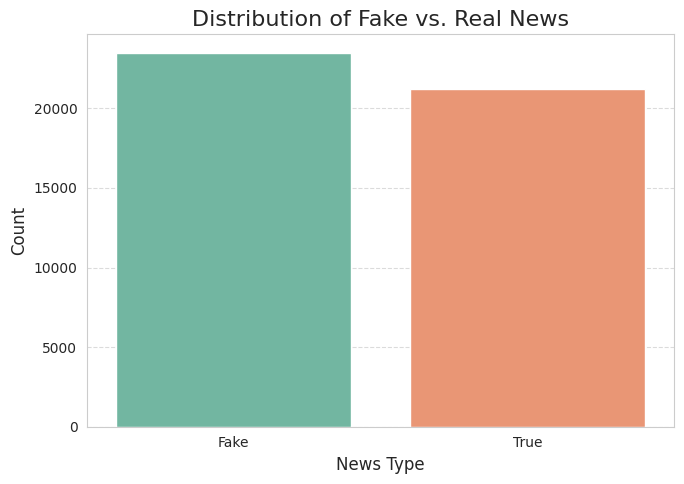


--- Missing Value Visualization (if applicable) ---
No missing values found in the dataset after cleaning, so a missing value visualization is not needed.


In [7]:
print("\n--- Visualizing Class Distribution (Fake vs Real News) ---")
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='Set2', hue='label', legend=False) # Add hue='label' and legend=False to resolve FutureWarning
plt.title('Distribution of Fake vs. Real News', fontsize=16)
plt.xlabel('News Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Fake', 'True'], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Missing Value Visualization (if applicable) ---")
# Since df.isnull().sum() showed no missing values, a heatmap would be blank.
# We can confirm this visually if desired, but it's not strictly necessary.
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values in the Dataset', fontsize=16)
    plt.show()
else:
    print("No missing values found in the dataset after cleaning, so a missing value visualization is not needed.")


--- Text/News Length Distribution ---


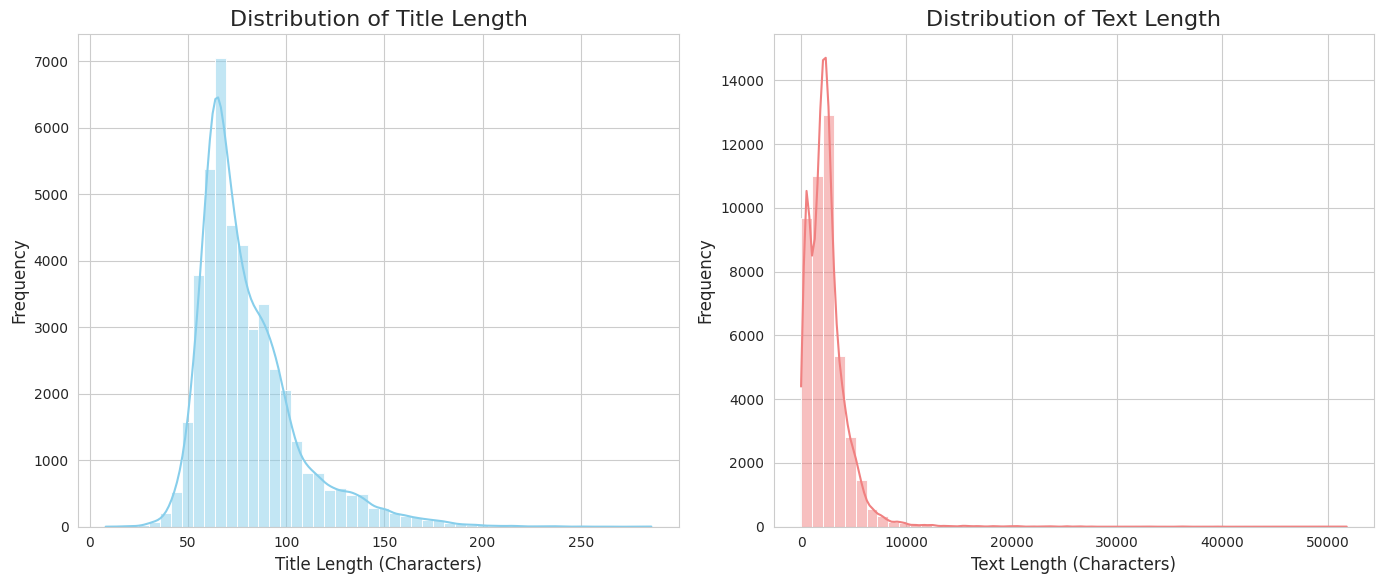


--- Word Count Distribution ---


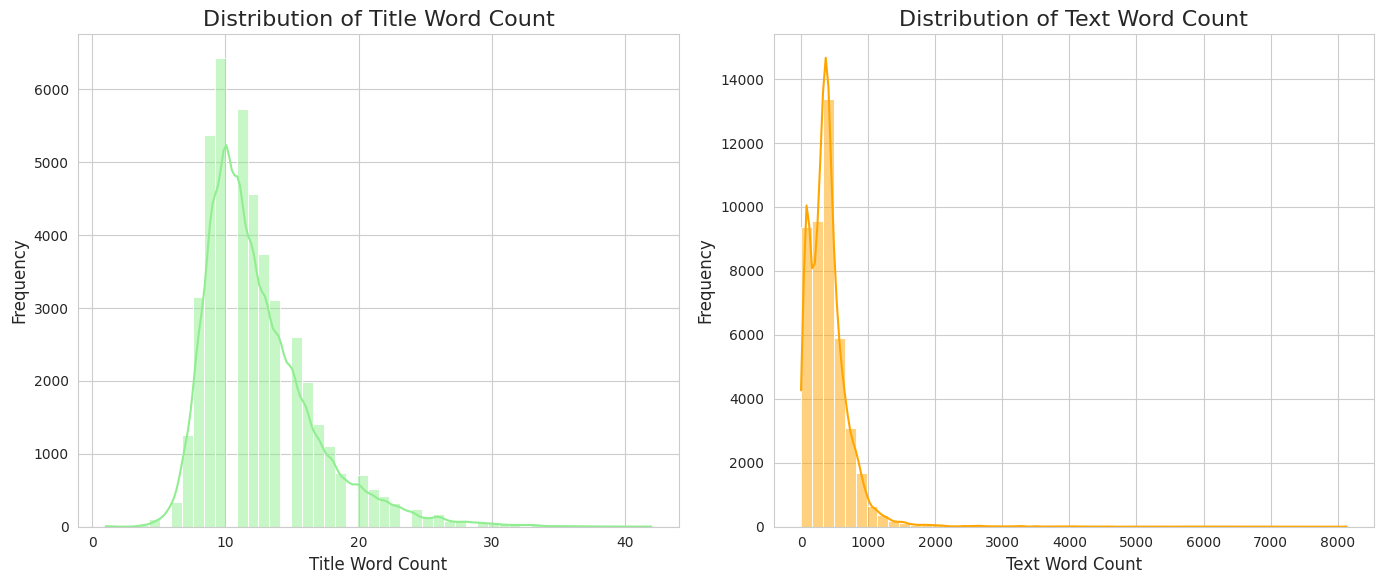

In [8]:
# Calculate text lengths and word counts
df['title_length'] = df['title'].apply(len)
df['text_length'] = df['text'].apply(len)
df['title_word_count'] = df['title'].apply(lambda x: len(x.split()))
df['text_word_count'] = df['text'].apply(lambda x: len(x.split()))

print("\n--- Text/News Length Distribution ---")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['title_length'], bins=50, kde=True, color='skyblue') # Removed palette='viridis' to resolve UserWarning
plt.title('Distribution of Title Length', fontsize=16)
plt.xlabel('Title Length (Characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

plt.subplot(1, 2, 2)
sns.histplot(df['text_length'], bins=50, kde=True, color='lightcoral') # Removed palette='viridis' to resolve UserWarning
plt.title('Distribution of Text Length', fontsize=16)
plt.xlabel('Text Length (Characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

print("\n--- Word Count Distribution ---")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['title_word_count'], bins=50, kde=True, color='lightgreen') # Removed palette='magma' to resolve UserWarning
plt.title('Distribution of Title Word Count', fontsize=16)
plt.xlabel('Title Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

plt.subplot(1, 2, 2)
sns.histplot(df['text_word_count'], bins=50, kde=True, color='orange') # Removed palette='magma' to resolve UserWarning
plt.title('Distribution of Text Word Count', fontsize=16)
plt.xlabel('Text Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()


--- Top Words Visualization ---


/tmp/ipykernel_2097/709153071.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=common_words_fake_title_df, palette='coolwarm')
/tmp/ipykernel_2097/709153071.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=common_words_true_title_df, palette='husl')
/tmp/ipykernel_2097/709153071.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=common_words_fake_text_df, palette='coolwarm')
/tmp/ipykernel_2097/709153071.py:56: FutureWarning: 

Passing `palette` without a

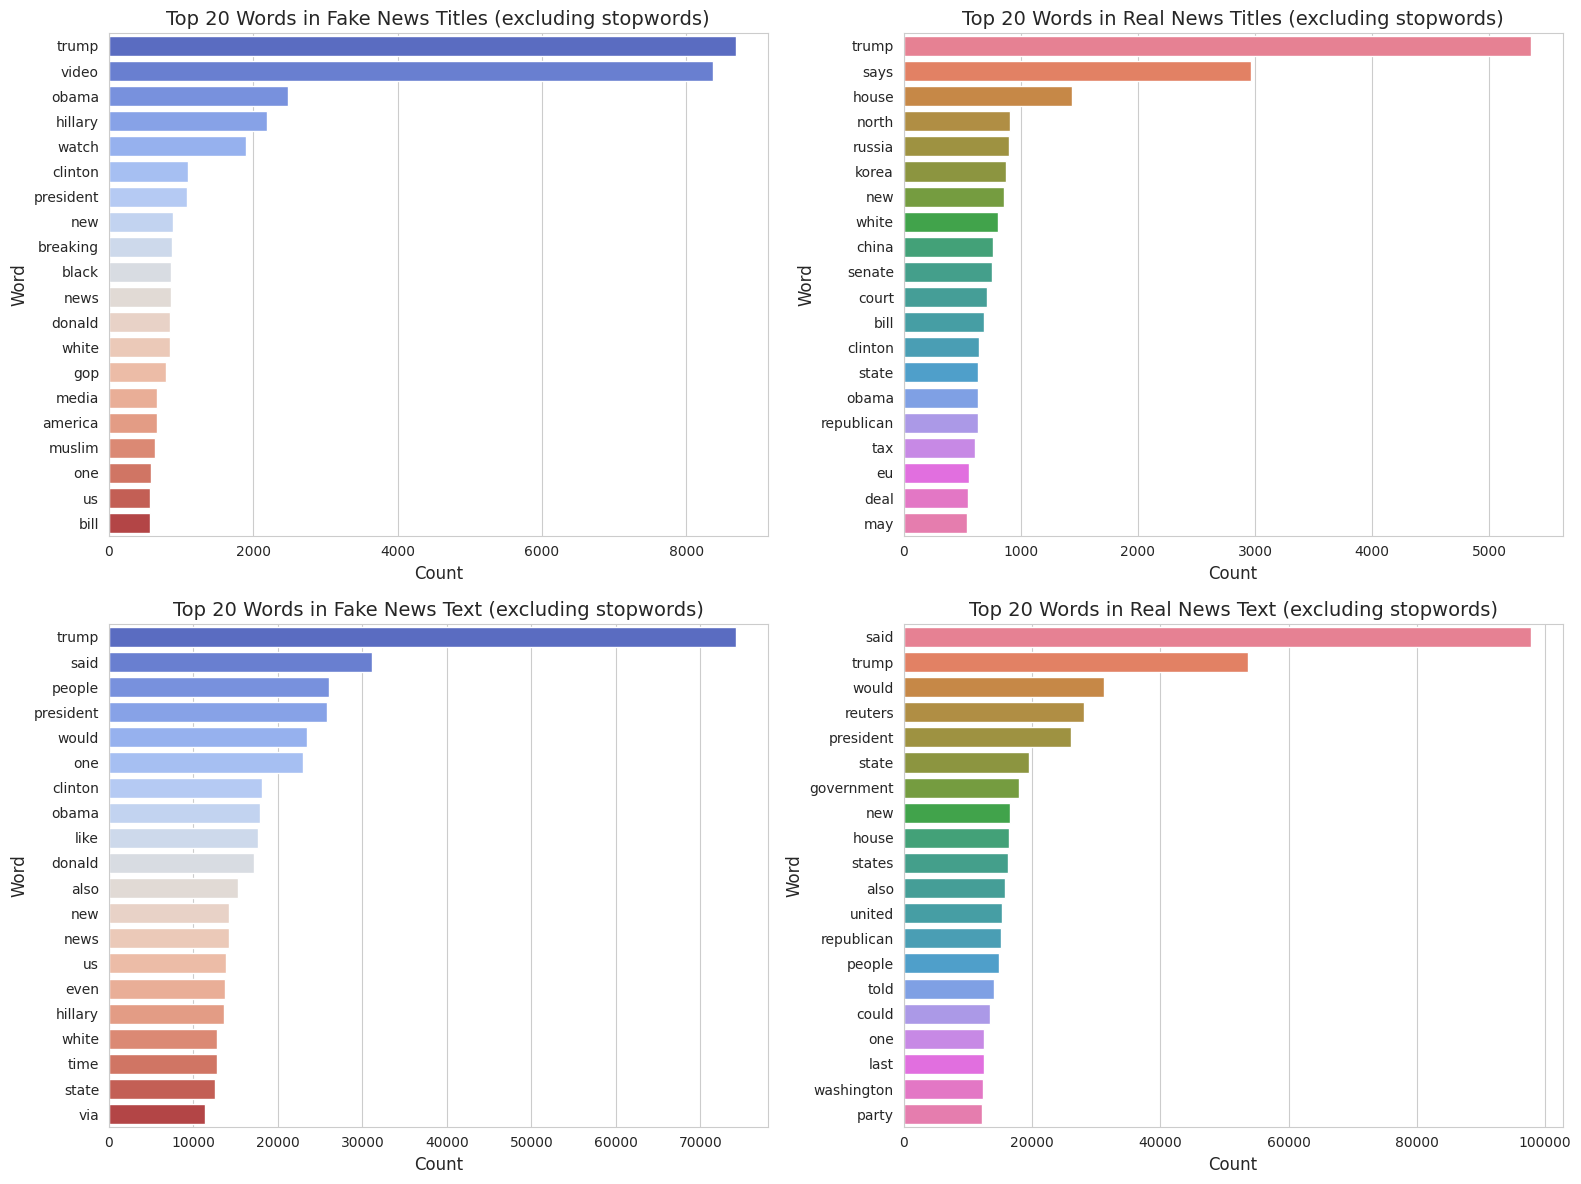


--- Correlation Visualization (where applicable) ---
Correlation visualization is not directly applicable to the current features ('title', 'text', 'subject', 'label') as they are primarily textual or categorical. Numerical features like text length and word count have been analyzed through their distributions instead of correlation with each other, as their relationship is generally linear.


In [9]:
print("\n--- Top Words Visualization ---")
stop_words = set(stopwords.words('english'))

def get_top_n_words(corpus, n=None):
    words = []
    for text in corpus:
        # Tokenize and convert to lowercase, remove punctuation
        tokens = [word.lower() for word in nltk.word_tokenize(text) if word.isalpha() and word.lower() not in stop_words]
        words.extend(tokens)
    fdist = nltk.FreqDist(words)
    return fdist.most_common(n)

# Top words in Fake News Titles
common_words_fake_title = get_top_n_words(df[df['label'] == 'fake']['title'], 20)
common_words_fake_title_df = pd.DataFrame(common_words_fake_title, columns=['Word', 'Count'])

# Top words in Real News Titles
common_words_true_title = get_top_n_words(df[df['label'] == 'true']['title'], 20)
common_words_true_title_df = pd.DataFrame(common_words_true_title, columns=['Word', 'Count'])

# Top words in Fake News Text
common_words_fake_text = get_top_n_words(df[df['label'] == 'fake']['text'], 20)
common_words_fake_text_df = pd.DataFrame(common_words_fake_text, columns=['Word', 'Count'])

# Top words in Real News Text
common_words_true_text = get_top_n_words(df[df['label'] == 'true']['text'], 20)
common_words_true_text_df = pd.DataFrame(common_words_true_text, columns=['Word', 'Count'])

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.barplot(x='Count', y='Word', data=common_words_fake_title_df, palette='coolwarm')
plt.title('Top 20 Words in Fake News Titles (excluding stopwords)', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.subplot(2, 2, 2)
sns.barplot(x='Count', y='Word', data=common_words_true_title_df, palette='husl')
plt.title('Top 20 Words in Real News Titles (excluding stopwords)', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.subplot(2, 2, 3)
sns.barplot(x='Count', y='Word', data=common_words_fake_text_df, palette='coolwarm')
plt.title('Top 20 Words in Fake News Text (excluding stopwords)', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.subplot(2, 2, 4)
sns.barplot(x='Count', y='Word', data=common_words_true_text_df, palette='husl')
plt.title('Top 20 Words in Real News Text (excluding stopwords)', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

print("\n--- Correlation Visualization (where applicable) ---")
print("Correlation visualization is not directly applicable to the current features ('title', 'text', 'subject', 'label') as they are primarily textual or categorical. Numerical features like text length and word count have been analyzed through their distributions instead of correlation with each other, as their relationship is generally linear.")

### 6. Text Preprocessing

In [10]:
# Initialize NLTK objects
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs (using raw string)
    text = re.sub(r'<.*?>+', '', text) # Remove HTML tags (using raw string)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation (using raw string)
    text = re.sub(r'\n', '', text) # Remove newline characters (using raw string)
    text = re.sub(r'\w*\d\w*', '', text) # Remove words containing numbers (using raw string)
    text = re.sub(r' +', ' ', text) # Remove extra whitespace (using raw string)

    # Tokenization and Stopword Removal and Lemmatization
    tokens = []
    for token in nltk.word_tokenize(text):
        if token.isalpha() and token not in stop_words:
            tokens.append(lemmatizer.lemmatize(token)) # Lemmatization

    return " ".join(tokens)

# Apply text cleaning to 'title' and 'text' columns
print("Cleaning and preprocessing 'title' and 'text' columns...")
df['cleaned_title'] = df['title'].apply(clean_text)
df['cleaned_text'] = df['text'].apply(clean_text)

# Combine cleaned title and text for the main feature
df['combined_text'] = df['cleaned_title'] + " " + df['cleaned_text']

print("Text preprocessing complete.")
print("\nDisplaying first 5 rows of original and cleaned text:")
print(df[['title', 'cleaned_title', 'text', 'cleaned_text', 'combined_text']].head())

Cleaning and preprocessing 'title' and 'text' columns...
Text preprocessing complete.

Displaying first 5 rows of original and cleaned text:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                       cleaned_title  \
0  donald trump sends embarrassing new year eve m...   
1  drunk bragging trump staffer started russian c...   
2  sheriff david clarke becomes internet joke thr...   
3  trump obsessed even obama name coded website i...   
4  pope francis called donald trump christmas speech   

                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it 

### 7. Train/Test Split

In [11]:
# Define features (X) and target (y)
X = df['combined_text']
y = df['label_encoded']

# Split the dataset into training and testing sets (80/20 split, stratified, reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (35748,)
Shape of X_test: (8937,)
Shape of y_train: (35748,)
Shape of y_test: (8937,)

Class distribution in training set:
label_encoded
0    0.5254
1    0.4746
Name: proportion, dtype: float64

Class distribution in testing set:
label_encoded
0    0.525344
1    0.474656
Name: proportion, dtype: float64


### 8. Convert News Text into Numerical Features

In [12]:
# Initialize TfidfVectorizer
# TF-IDF (Term Frequency-Inverse Document Frequency) is used here to convert text
# documents into a matrix of TF-IDF features. It reflects how important a word is
# to a document in a corpus. It gives more weight to words that are rare across
# all documents but common in a specific document, helping to capture distinct
# features for classification.
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting max_features to manage dimensionality

# Fit the vectorizer only on the training data to prevent data leakage
tfidf_vectorizer.fit(X_train)

# Transform both training and testing data
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("News text converted to numerical features using TF-IDF.")
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("\nFitted TfidfVectorizer saved as 'tfidf_vectorizer.pkl'")

News text converted to numerical features using TF-IDF.
Shape of X_train_tfidf: (35748, 5000)
Shape of X_test_tfidf: (8937, 5000)

Fitted TfidfVectorizer saved as 'tfidf_vectorizer.pkl'


### 9. Classification Models

In [13]:
# Initialize and train classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

model_performance = {}

print("Training classification models...")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_tfidf, y_train)
    print(f"{name} trained successfully.")
    model_performance[name] = model # Store trained model

print("\nAll models trained.")

Training classification models...

Training Logistic Regression...
Logistic Regression trained successfully.

Training Multinomial Naive Bayes...
Multinomial Naive Bayes trained successfully.

Training Linear SVM...
Linear SVM trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

All models trained.


### 10. Model Evaluation

In [14]:
evaluation_results = []

print("Evaluating classification models...")
for name, model in models.items():
    print(f"\nEvaluating {name}...")

    # Predict on the test set
    y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # ROC-AUC is only applicable for models that can provide probability estimates
    roc_auc = None
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    elif hasattr(model, "decision_function"):
        # For LinearSVC, decision_function provides a score, but it's not a probability
        # Can convert to probability if needed, but for now, we'll note it.
        try:
            y_pred_score = model.decision_function(X_test_tfidf)
            roc_auc = roc_auc_score(y_test, y_pred_score)
        except Exception as e:
            print(f"Could not calculate ROC-AUC for {name} with decision_function: {e}")
            roc_auc = None

    # Store results
    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"  ROC-AUC: {roc_auc:.4f}")

    # Confusion Matrix (optional to print here, will visualize later)
    # cm = confusion_matrix(y_test, y_pred)
    # print(f"  Confusion Matrix:\n{cm}")

# Create a comparison DataFrame
model_comparison_df = pd.DataFrame(evaluation_results)
model_comparison_df = model_comparison_df.sort_values(by='F1-Score', ascending=False)

print("\n--- Model Performance Comparison ---")
print(model_comparison_df.to_string(index=False))

# Save the model comparison DataFrame for later use in the dashboard
joblib.dump(model_comparison_df, 'model_comparison_df.pkl')
print("\nModel comparison DataFrame saved as 'model_comparison_df.pkl'")

Evaluating classification models...

Evaluating Logistic Regression...
  Accuracy: 0.9865
  Precision: 0.9865
  Recall: 0.9865
  F1-Score: 0.9865
  ROC-AUC: 0.9989

Evaluating Multinomial Naive Bayes...
  Accuracy: 0.9292
  Precision: 0.9292
  Recall: 0.9292
  F1-Score: 0.9292
  ROC-AUC: 0.9797

Evaluating Linear SVM...
  Accuracy: 0.9946
  Precision: 0.9946
  Recall: 0.9946
  F1-Score: 0.9946
  ROC-AUC: 0.9998

Evaluating Decision Tree...
  Accuracy: 0.9947
  Precision: 0.9947
  Recall: 0.9947
  F1-Score: 0.9947
  ROC-AUC: 0.9947

Evaluating Random Forest...
  Accuracy: 0.9975
  Precision: 0.9975
  Recall: 0.9975
  F1-Score: 0.9975
  ROC-AUC: 0.9999

--- Model Performance Comparison ---
                  Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
          Random Forest  0.997538   0.997538 0.997538  0.997538 0.999929
          Decision Tree  0.994741   0.994741 0.994741  0.994741 0.994710
             Linear SVM  0.994629   0.994632 0.994629  0.994629 0.999772
    Logisti

### 11. Model Comparison Visualization


--- Model Comparison Visualizations ---


/tmp/ipykernel_2097/3993911174.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=model_comparison_df.sort_values(by=metric, ascending=False), palette=colors[i])
/tmp/ipykernel_2097/3993911174.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=model_comparison_df.sort_values(by=metric, ascending=False), palette=colors[i])
/tmp/ipykernel_2097/3993911174.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=model_comparison_df.sort_values(by=metric, ascending=Fals

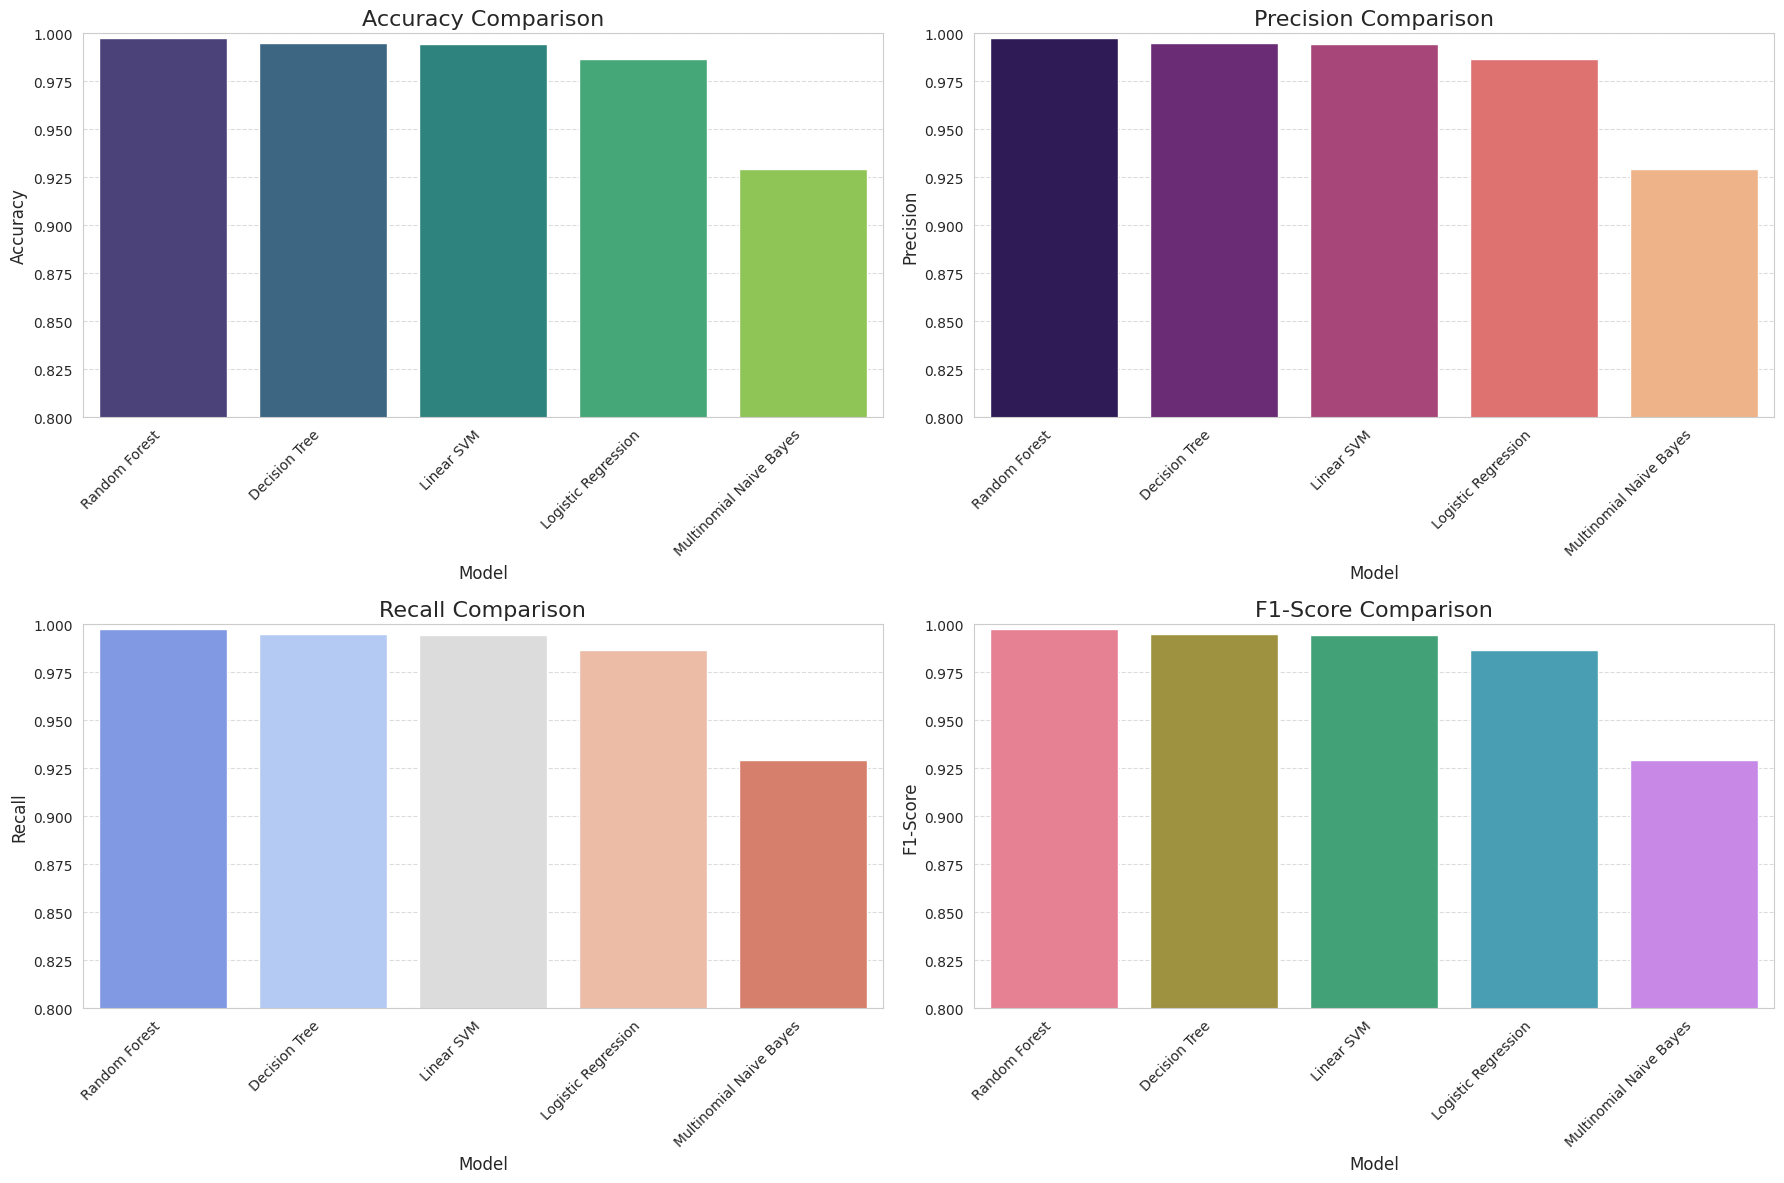


--- Best Performing Model (based on F1-Score) ---
Model: Random Forest
Accuracy: 0.9975
Precision: 0.9975
Recall: 0.9975
F1-Score: 0.9975
ROC-AUC: 0.9999

Best model name saved as 'best_model_name.pkl'


In [15]:
print("\n--- Model Comparison Visualizations ---")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['viridis', 'magma', 'coolwarm', 'husl']

plt.figure(figsize=(18, 12))

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1)
    sns.barplot(x='Model', y=metric, data=model_comparison_df.sort_values(by=metric, ascending=False), palette=colors[i])
    plt.title(f'{metric} Comparison', fontsize=16)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylim(0.8, 1.0) # Set a consistent y-axis limit for better comparison
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Identify the best performing model based on F1-Score
best_model_name = model_comparison_df.loc[model_comparison_df['F1-Score'].idxmax()]['Model']
best_model_metrics = model_comparison_df.loc[model_comparison_df['F1-Score'].idxmax()]

print(f"\n--- Best Performing Model (based on F1-Score) ---")
print(f"Model: {best_model_name}")
print(f"Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"Precision: {best_model_metrics['Precision']:.4f}")
print(f"Recall: {best_model_metrics['Recall']:.4f}")
print(f"F1-Score: {best_model_metrics['F1-Score']:.4f}")
if best_model_metrics['ROC-AUC'] is not None:
    print(f"ROC-AUC: {best_model_metrics['ROC-AUC']:.4f}")

# Store the best model name for later use
joblib.dump(best_model_name, 'best_model_name.pkl')
print("\nBest model name saved as 'best_model_name.pkl'")

### 12. Best Model

--- Best Performing Model Details ---
Model Name: Random Forest
Accuracy: 0.9975
Precision: 0.9975
Recall: 0.9975
F1-Score: 0.9975
ROC-AUC: 0.9999

--- Confusion Matrix for the Best Model ---


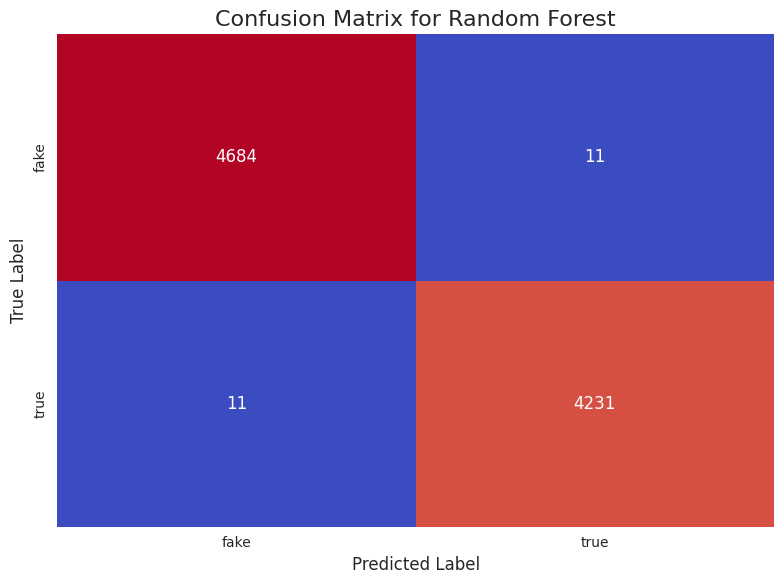

In [16]:
print("--- Best Performing Model Details ---")
# Load the best model name and comparison dataframe
best_model_name = joblib.load('best_model_name.pkl')
model_comparison_df = joblib.load('model_comparison_df.pkl')

best_model_metrics = model_comparison_df[model_comparison_df['Model'] == best_model_name].iloc[0]
best_model = model_performance[best_model_name]

print(f"Model Name: {best_model_metrics['Model']}")
print(f"Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"Precision: {best_model_metrics['Precision']:.4f}")
print(f"Recall: {best_model_metrics['Recall']:.4f}")
print(f"F1-Score: {best_model_metrics['F1-Score']:.4f}")
if best_model_metrics['ROC-AUC'] is not None:
    print(f"ROC-AUC: {best_model_metrics['ROC-AUC']:.4f}")
else:
    print("ROC-AUC: Not applicable or could not be calculated for this model")

# Generate Confusion Matrix for the best model
print("\n--- Confusion Matrix for the Best Model ---")
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False,
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix for {best_model_name}', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 13. Save the Complete Prediction Pipeline

In [17]:
print("Saving the complete prediction pipeline...")

# Save the best trained model
best_model_name = joblib.load('best_model_name.pkl')
best_model = model_performance[best_model_name]
joblib.dump(best_model, f'{best_model_name.replace(" ", "_").lower()}_model.pkl')
print(f"Best model ('{best_model_name}') saved as '{best_model_name.replace(" ", "_").lower()}_model.pkl'")

# TF-IDF vectorizer is already saved in section 8
# LabelEncoder is already saved in section 4

print("\nAll necessary pipeline components saved.")

Saving the complete prediction pipeline...
Best model ('Random Forest') saved as 'random_forest_model.pkl'

All necessary pipeline components saved.


### 14. New News Prediction Function

In [18]:
print("Creating the 'predict_news' function...")

# Load the saved pipeline components
loaded_label_encoder = joblib.load('label_encoder.pkl')
loaded_tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')
loaded_best_model_name = joblib.load('best_model_name.pkl')

# Dynamically load the best model based on its saved name
model_filename = f'{loaded_best_model_name.replace(" ", "_").lower()}_model.pkl'
loaded_best_model = joblib.load(model_filename)

def predict_news(news_text):
    # 1. Apply the same text preprocessing
    cleaned_news = clean_text(news_text)

    # 2. Transform the text using the saved TF-IDF vectorizer
    news_tfidf = loaded_tfidf_vectorizer.transform([cleaned_news])

    # 3. Pass it to the best trained model
    prediction_encoded = loaded_best_model.predict(news_tfidf)

    # 4. Convert the numerical prediction back to the original label using LabelEncoder
    prediction_label = loaded_label_encoder.inverse_transform(prediction_encoded)[0]

    # 5. Display confidence/probability when supported by the selected model
    confidence = None
    if hasattr(loaded_best_model, "predict_proba"):
        prediction_proba = loaded_best_model.predict_proba(news_tfidf)[0]
        confidence = max(prediction_proba) * 100

    print("\nNews Article:")
    print(news_text)
    print("\nPrediction:")
    print(prediction_label.upper())
    if confidence is not None:
        print(f"Confidence: {confidence:.2f}%")

# Example Usage:
print("\n--- Example Prediction --- ")
example_fake_news = "BREAKING: Pope Francis endorses Donald Trump for President - Vatican stuns world with unprecedented announcement!"
predict_news(example_fake_news)

example_true_news = "Reuters reports on latest economic data showing modest growth in Q3."
predict_news(example_true_news)

example_neutral_news = "Scientists discover new species of deep-sea fish near Mariana Trench."
predict_news(example_neutral_news)

print("\n'predict_news' function created and demonstrated.")

Creating the 'predict_news' function...

--- Example Prediction --- 

News Article:
BREAKING: Pope Francis endorses Donald Trump for President - Vatican stuns world with unprecedented announcement!

Prediction:
FAKE
Confidence: 90.00%

News Article:
Reuters reports on latest economic data showing modest growth in Q3.

Prediction:
TRUE
Confidence: 67.00%

News Article:
Scientists discover new species of deep-sea fish near Mariana Trench.

Prediction:
FAKE
Confidence: 97.00%

'predict_news' function created and demonstrated.


### 15. Interactive Dashboard

In [19]:
print("Creating interactive dashboard...")

# --- Load necessary components for the dashboard ---
loaded_label_encoder = joblib.load('label_encoder.pkl')
loaded_tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')
loaded_best_model_name = joblib.load('best_model_name.pkl')
model_comparison_df = joblib.load('model_comparison_df.pkl')
model_filename = f'{loaded_best_model_name.replace(" ", "_").lower()}_model.pkl'
loaded_best_model = joblib.load(model_filename)

# Get best model metrics for display
best_model_metrics = model_comparison_df[model_comparison_df['Model'] == loaded_best_model_name].iloc[0]

# --- Dashboard Structure ---

# 1. Dataset Overview
num_records = df.shape[0]
num_features = df.shape[1]
fake_count = df['label'].value_counts()['fake']
true_count = df['label'].value_counts()['true']

dataset_overview_html = f"""
    <div style='border: 1px solid #ccc; padding: 15px; border-radius: 5px; background-color: #f0f0f0; color: #333;'>
        <h3 style='color: #0056b3;'>Dataset Overview</h3>
        <ul>
            <li><b>Total Records:</b> {num_records}</li>
            <li><b>Number of Features:</b> {num_features}</li>
            <li><b>Fake News Count:</b> {fake_count}</li>
            <li><b>Real News Count:</b> {true_count}</li>
        </ul>
    </div>
"""

# 2. Data Visualization (Placeholder for previously generated plots - actual plots will be displayed via their code)
visualization_info_html = """
    <div style='border: 1px solid #ccc; padding: 15px; border-radius: 5px; background-color: #f0f0f0; color: #333;'>
        <h3 style='color: #0056b3;'>Data Visualizations</h3>
        <p>The key exploratory data analysis plots (Fake vs Real distribution, text length, word counts, top words) are displayed above in Section 5.</p>
    </div>
"""

# 3. Model Performance
model_performance_html = f"""
    <div style='border: 1px solid #ccc; padding: 15px; border-radius: 5px; background-color: #f0f0f0; color: #333;'>
        <h3 style='color: #0056b3;'>Model Performance</h3>
        <h4 style='color: #0056b3;'>Best Model: {loaded_best_model_name}</h4>
        <ul>
            <li><b>Accuracy:</b> {best_model_metrics['Accuracy']:.4f}</li>
            <li><b>Precision:</b> {best_model_metrics['Precision']:.4f}</li>
            <li><b>Recall:</b> {best_model_metrics['Recall']:.4f}</li>
            <li><b>F1-Score:</b> {best_model_metrics['F1-Score']:.4f}</li>
            <li><b>ROC-AUC:</b> {best_model_metrics['ROC-AUC']:.4f}</li>
        </ul>
        <h4 style='color: #0056b3;'>All Model Comparison:</h4>
        {model_comparison_df.to_html(index=False)}
    </div>
"""

# 4. Confusion Matrix (placeholder, actual plot is above)
confusion_matrix_info_html = f"""
    <div style='border: 1px solid #ccc; padding: 15px; border-radius: 5px; background-color: #f0f0f0; color: #333;'>
        <h3 style='color: #0056b3;'>Confusion Matrix</h3>
        <p>The confusion matrix for the best model ({loaded_best_model_name}) is displayed above in Section 12.</p>
    </div>
"""

# 5. Fake News Prediction (Interactive Widget)
news_input = widgets.Textarea(
    value='',
    placeholder='Enter news article text here...',
    description='News Text:',
    disabled=False,
    layout=Layout(width='auto', height='150px')
)

predict_button = widgets.Button(
    description='Predict',
    disabled=False,
    button_style='info',
    tooltip='Click to predict if the news is Fake or Real',
    icon='search'
)

prediction_output = widgets.Output()

def on_predict_button_clicked(b):
    with prediction_output:
        prediction_output.clear_output()
        if news_input.value:
            cleaned_news = clean_text(news_input.value)
            news_tfidf = loaded_tfidf_vectorizer.transform([cleaned_news])

            prediction_encoded = loaded_best_model.predict(news_tfidf)
            prediction_label = loaded_label_encoder.inverse_transform(prediction_encoded)[0]

            confidence = None
            if hasattr(loaded_best_model, "predict_proba"):
                prediction_proba = loaded_best_model.predict_proba(news_tfidf)[0]
                confidence = max(prediction_proba) * 100

            print("--- Prediction Results ---")
            print(f"Prediction: {prediction_label.upper()}")
            if confidence is not None:
                print(f"Confidence: {confidence:.2f}%")

        else:
            print("Please enter news text for prediction.")

predict_button.on_click(on_predict_button_clicked)

prediction_widget = VBox([
    widgets.HTML("<h3 style='color: #0056b3;'>Fake News Prediction</h3>"),
    news_input,
    predict_button,
    prediction_output
])

# Display the dashboard sections
display(HTML(f"""
<div style='background-color: #e6f2ff; padding: 20px; border-radius: 8px;'>
    <h2 style='color: #0056b3; text-align: center;'>Fake News Detection System Dashboard</h2><hr style='border-color: #0056b3;'>
    {dataset_overview_html}
    <br>
    {visualization_info_html}
    <br>
    {model_performance_html}
    <br>
    {confusion_matrix_info_html}
    <br>
"""))
display(prediction_widget)
display(HTML("</div>"))

print("Dashboard created successfully!")

Creating interactive dashboard...


Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.997538,0.997538,0.997538,0.997538,0.999929
Decision Tree,0.994741,0.994741,0.994741,0.994741,0.994710
Linear SVM,0.994629,0.994632,0.994629,0.994629,0.999772
Logistic Regression,0.986461,0.986462,0.986461,0.986461,0.998932
Multinomial Naive Bayes,0.929171,0.929176,0.929171,0.929152,0.979690


Dashboard created successfully!
